# Brouillon 5 : Monte Carlo des estimateurs

Jusqu'ici chaque méthode a été testée sur un seul jeu de données. Un bon estimateur doit être sans biais
*en moyenne*, et son IC à 95 % doit contenir la vraie valeur dans ~95 % des simulations (couverture).
Deuxième question : à partir de quelle taille d'échantillon le Double ML devient-il fiable ?

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
import doubleml as dml

In [2]:
def simuler(n=5000, effet=0.0, seed=123):
    rng = np.random.default_rng(seed)
    temperature = rng.normal(20, 6, n)
    glaces = 2 * temperature + 0.05 * temperature**2 + rng.normal(0, 5, n)
    noyades = 0.3 * temperature + 0.01 * temperature**2 + effet * glaces + rng.normal(0, 2, n)
    return pd.DataFrame({"temperature": temperature, "glaces": glaces, "noyades": noyades})


def ols(df, variables):
    m = sm.OLS(df.noyades, sm.add_constant(df[variables])).fit()
    return m.params["glaces"], *m.conf_int().loc["glaces"].tolist()


def double_ml(df, n_estimators=100, min_samples_leaf=5, seed=0):
    donnees = dml.DoubleMLData(df, y_col="noyades", d_cols="glaces", x_cols=["temperature"])
    ml_l = RandomForestRegressor(n_estimators=n_estimators, min_samples_leaf=min_samples_leaf, random_state=seed, n_jobs=-1)
    ml_m = RandomForestRegressor(n_estimators=n_estimators, min_samples_leaf=min_samples_leaf, random_state=seed, n_jobs=-1)
    np.random.seed(seed)
    m = dml.DoubleMLPLR(donnees, ml_l, ml_m, n_folds=5)
    m.fit()
    return m.coef[0], *m.confint().iloc[0].tolist()

## 1. Temps de calcul
Avant de lancer 100+ répétitions, je mesure le temps d'une répétition.

In [3]:
debut = time.time()
double_ml(simuler(seed=1))
print("DML n = 5000, 100 arbres :", round(time.time() - debut, 2), "s")
debut = time.time()
double_ml(simuler(n=500, seed=1))
print("DML n = 500,  100 arbres :", round(time.time() - debut, 2), "s")

DML n = 5000, 100 arbres : 2.37 s


DML n = 500,  100 arbres : 2.0 s


## 2. Monte Carlo à n = 5000

In [4]:
def une_repetition(n, effet, seed):
    df = simuler(n=n, effet=effet, seed=seed)
    df["temperature2"] = df.temperature**2
    res = {
        "OLS naïf": ols(df, ["glaces"]),
        "OLS + T + T²": ols(df, ["glaces", "temperature", "temperature2"]),
        "OLS + T (sans carré)": ols(df, ["glaces", "temperature"]),
        "Double ML": double_ml(df, seed=seed),
    }
    return [{"methode": k, "seed": seed, "effet": v[0], "bas": v[1], "haut": v[2]} for k, v in res.items()]

debut = time.time()
lignes = []
for r in range(100):
    lignes += une_repetition(5000, 0.0, seed=10_000 + r)
mc = pd.DataFrame(lignes)
print("temps total :", round(time.time() - debut, 1), "s")

temps total : 237.4 s


In [5]:
mc["couvre"] = (mc.bas <= 0) & (mc.haut >= 0)
resume = mc.groupby("methode", sort=False).agg(biais_moyen=("effet", "mean"), ecart_type=("effet", "std"),
                                                couverture=("couvre", "mean"))
resume["couverture"] *= 100
resume.round(4)

,biais_moyen,ecart_type,couverture
methode,,,
OLS naïf,0.1680,0.0012,0.0
OLS + T + T²,0.0008,0.0061,96.0
OLS + T (sans carré),0.0415,0.0053,0.0
Double ML,0.0031,0.0065,90.0


- OLS naïf : biais 0.17 et couverture 0 % : l'IC est étroit autour d'une mauvaise valeur, à chaque fois.
- OLS sans le carré : même problème, en plus petit (biais 0.04, couverture 0 %).
- OLS + T + T² : sans biais, couverture 96 % (le modèle est exactement le bon).
- Double ML : biais moyen 0.003 (environ la moitié d'un écart-type) et couverture 90 %, un peu sous 95 %.
  Avec 100 répétitions, l'incertitude sur la couverture est d'environ ± 3 points, mais 90 % reste un peu bas.
  Hypothèse : biais de régularisation des forêts (min_samples_leaf = 5 lisse un peu la courbure en T²).
  À tester plus bas avec min_samples_leaf = 1.

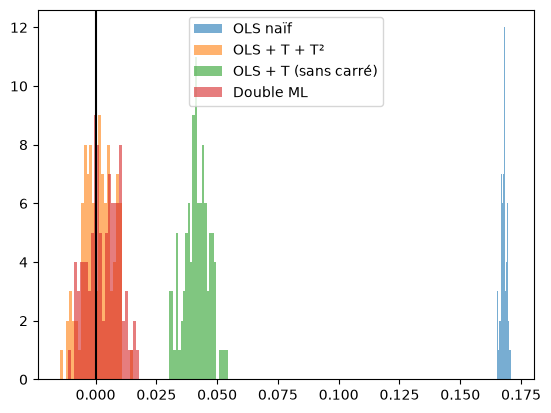

In [6]:
fig, ax = plt.subplots()
for nom, g in mc.groupby("methode", sort=False):
    ax.hist(g.effet, bins=25, alpha=0.6, label=nom)
ax.axvline(0, color="k")
ax.legend()
plt.show()

## 3. Taille d'échantillon (Double ML)
50 répétitions pour chaque n.

In [7]:
debut = time.time()
lignes_n = []
for n in [200, 500, 1000, 2000, 5000]:
    for r in range(50):
        est, bas, haut = double_ml(simuler(n=n, seed=20_000 + r), seed=r)
        lignes_n.append({"n": n, "effet": est, "bas": bas, "haut": haut})
mc_n = pd.DataFrame(lignes_n)
print("temps :", round(time.time() - debut, 1), "s")
mc_n["largeur"] = mc_n.haut - mc_n.bas
mc_n["couvre"] = (mc_n.bas <= 0) & (mc_n.haut >= 0)
mc_n.groupby("n").agg(biais=("effet", "mean"), ecart_type=("effet", "std"),
                      largeur_ic=("largeur", "mean"), couverture=("couvre", "mean")).round(4)

temps : 521.4 s


,biais,ecart_type,largeur_ic,couverture
n,,,,
200,0.0527,0.0260,0.1180,0.54
500,0.0175,0.0203,0.0771,0.90
1000,0.0138,0.0161,0.0529,0.76
2000,0.0036,0.0105,0.0366,0.96
5000,0.0005,0.0052,0.0224,0.96


Le Double ML a besoin de données : à n = 200 le biais est de 0.05 et la couverture tombe à 54 %. Les forêts
estiment mal les fonctions de nuisance sur 160 observations par fold, et le biais qui reste n'est plus
négligeable devant l'écart-type. La couverture devient correcte vers n = 2000.
(La valeur à n = 1000, 76 %, plus basse qu'à n = 500, rappelle qu'avec 50 répétitions ces pourcentages sont
assez bruités.)

## 4. Pistes : vitesse et sous-couverture
Temps total ~13 min : trop pour le notebook final. Est-ce que `n_jobs=-1` coûte cher sur les petits échantillons
(lancement des processus) ?

In [8]:
def double_ml_jobs(df, n_jobs, min_samples_leaf=5, seed=0):
    donnees = dml.DoubleMLData(df, y_col="noyades", d_cols="glaces", x_cols=["temperature"])
    ml_l = RandomForestRegressor(n_estimators=100, min_samples_leaf=min_samples_leaf, random_state=seed, n_jobs=n_jobs)
    ml_m = RandomForestRegressor(n_estimators=100, min_samples_leaf=min_samples_leaf, random_state=seed, n_jobs=n_jobs)
    np.random.seed(seed)
    m = dml.DoubleMLPLR(donnees, ml_l, ml_m, n_folds=5)
    m.fit()
    return m.coef[0], *m.confint().iloc[0].tolist()

for n in [500, 5000]:
    d = simuler(n=n, seed=1)
    for jobs in [1, -1]:
        debut = time.time()
        double_ml_jobs(d, jobs)
        print(f"n = {n}, n_jobs = {jobs} : {time.time() - debut:.2f} s")

n = 500, n_jobs = 1 : 1.15 s


n = 500, n_jobs = -1 : 2.03 s


n = 5000, n_jobs = 1 : 4.10 s


n = 5000, n_jobs = -1 : 2.29 s


Sous-couverture : même Monte Carlo (50 répétitions, n = 5000) avec min_samples_leaf = 1 et 5.

In [9]:
lignes_leaf = []
for leaf in [1, 5]:
    for r in range(50):
        est, bas, haut = double_ml_jobs(simuler(seed=10_000 + r), n_jobs=-1, min_samples_leaf=leaf, seed=r)
        lignes_leaf.append({"leaf": leaf, "effet": est, "couvre": bas <= 0 <= haut})
pd.DataFrame(lignes_leaf).groupby("leaf").agg(biais=("effet", "mean"), ecart_type=("effet", "std"),
                                              couverture=("couvre", "mean")).round(4)

,biais,ecart_type,couverture
leaf,,,
1,0.0015,0.0085,0.76
5,0.0023,0.0066,0.88


Vitesse : `n_jobs=1` est 2 fois plus rapide à n = 500 (le lancement des processus coûte plus cher que le calcul),
mais 2 fois plus lent à n = 5000. Dans `src/`, je choisis `n_jobs` selon la taille de l'échantillon.

Sous-couverture : l'hypothèse est fausse. Avec min_samples_leaf = 1, le biais baisse un peu, mais les
estimations deviennent plus dispersées (écart-type 0.0085) et la couverture tombe à 76 %.
Ce qui compte surtout : l'écart-type réel des estimations (≈ 0.0066 avec leaf = 5) est plus grand que l'écart-type
annoncé par DoubleML (≈ 0.0057, voir le brouillon 2). L'IC est donc un peu trop étroit : les erreurs d'estimation
des forêts ne sont pas complètement négligeables à n = 5000. C'est un résultat connu : les garanties du Double ML
sont asymptotiques, et la qualité des modèles de nuisance compte.

Je garde min_samples_leaf = 5 et je présente honnêtement la couverture (~90 %) dans le notebook final.
Pour le notebook final : 100 répétitions à n = 5000 (~4 min) et 50 répétitions par taille (~6 min).